In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [45]:
df=pd.read_csv('Wholesale customers data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [47]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [48]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [49]:
df.isna().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [50]:
df_spend = df.drop(columns=["Channel", "Region"])

In [51]:
features = df_spend.columns
features

Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'], dtype='object')

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_spend)

In [53]:
scaled_data.mean(axis=0)

array([-3.43159844e-17,  0.00000000e+00, -4.03717464e-17,  3.63345717e-17,
        2.42230478e-17, -8.07434927e-18])

In [54]:
scaled_data.std(axis=0)

array([1., 1., 1., 1., 1., 1.])

In [55]:
from sklearn.cluster import KMeans
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

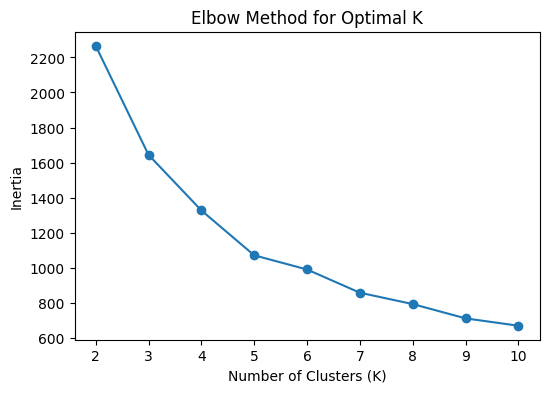

In [56]:
plt.figure(figsize=(6,4))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [57]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

In [58]:
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"K = {k}, Silhouette Score = {score:.3f}")


K = 2, Silhouette Score = 0.400
K = 3, Silhouette Score = 0.458
K = 4, Silhouette Score = 0.349
K = 5, Silhouette Score = 0.369


In [59]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,1


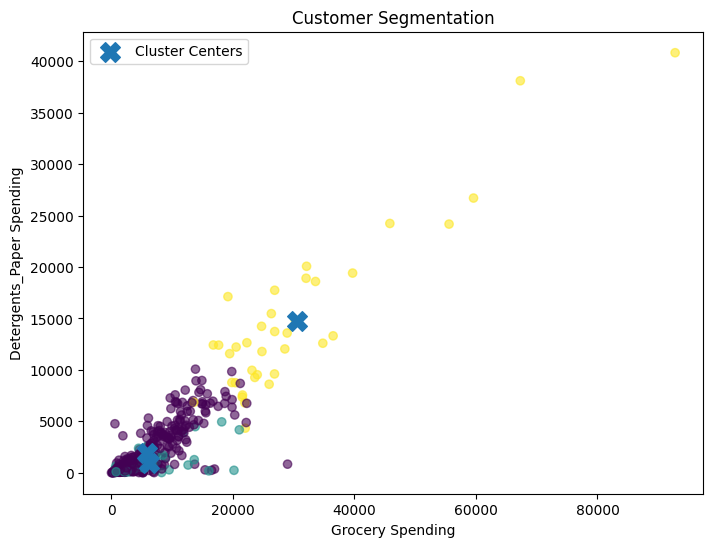

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Grocery"],
    df["Detergents_Paper"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

# Cluster centers (inverse scaling)
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, features.get_loc("Grocery")],
    centers[:, features.get_loc("Detergents_Paper")],
    marker="X",
    s=200,
    label="Cluster Centers"
)

plt.xlabel("Grocery Spending")
plt.ylabel("Detergents_Paper Spending")
plt.title("Customer Segmentation")
plt.legend()
plt.show()

In [61]:
cluster_profile = df.groupby("Cluster")[features].mean()
cluster_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,8935.500000,4228.528571,5848.034286,2167.231429,1913.605714,1102.120000
1,34540.113208,5860.358491,6122.622642,9841.735849,981.471698,3664.245283
2,8704.864865,20534.405405,30466.243243,1932.621622,14758.837838,2459.351351


In [62]:
for i in cluster_profile.index:
    print(f"\nCluster {i}")
    print(cluster_profile.loc[i])


Cluster 0
Fresh               8935.500000
Milk                4228.528571
Grocery             5848.034286
Frozen              2167.231429
Detergents_Paper    1913.605714
Delicassen          1102.120000
Name: 0, dtype: float64

Cluster 1
Fresh               34540.113208
Milk                 5860.358491
Grocery              6122.622642
Frozen               9841.735849
Detergents_Paper      981.471698
Delicassen           3664.245283
Name: 1, dtype: float64

Cluster 2
Fresh                8704.864865
Milk                20534.405405
Grocery             30466.243243
Frozen               1932.621622
Detergents_Paper    14758.837838
Delicassen           2459.351351
Name: 2, dtype: float64


In [63]:
from sklearn.cluster import KMeans
kmeans_alt = KMeans(n_clusters=3, random_state=99)
alt_clusters = kmeans_alt.fit_predict(scaled_data)



In [64]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(clusters, alt_clusters)
ari_score

0.4988943105211124

In [65]:
from sklearn.cluster import KMeans
import numpy as np

# Re-run K-Means with a different random state
kmeans_alt = KMeans(n_clusters=3, random_state=99)
alt_clusters = kmeans_alt.fit_predict(scaled_data)

# Compare cluster assignments
comparison = (clusters == alt_clusters)

# Count same vs different assignments
unique, counts = np.unique(comparison, return_counts=True)
dict(zip(unique, counts))

{np.False_: np.int64(57), np.True_: np.int64(383)}